<a href="https://colab.research.google.com/github/lankelasharanya04-crypto/datascience_tasks/blob/main/Heart_Disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# import necessary  libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ML LIBRARIES
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.datasets import load_breast_cancer

In [4]:
# loading dataset
df = pd.read_csv("heart.csv")
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
#Checking for null values
df.isnull().sum()

,0
Unnamed: 0,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0


In [6]:
# remove unnamed column from dataset
df.drop("Unnamed: 0",axis=1,inplace=True)
df


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [7]:
#checking for unique values in target column
df["target"].unique()


array([1, 0])

In [8]:
#checking for unique values in gender column
df["sex"].unique()

array([1, 0])

<Axes: xlabel='target', ylabel='Count'>

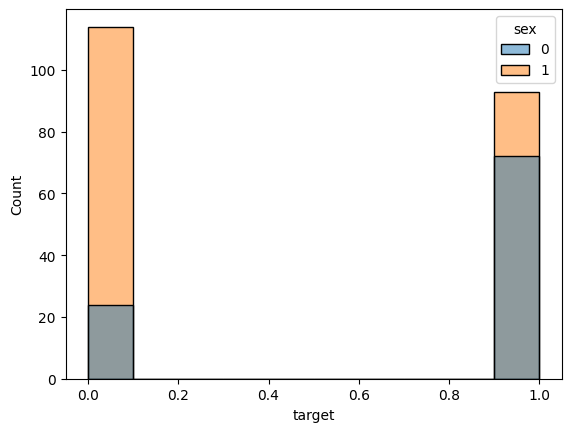

In [9]:
# plotting hisplot for target and gender to determine which gender has more heart diseases
sns.histplot(x="target",data=df,hue="sex")

<Axes: xlabel='age', ylabel='Count'>

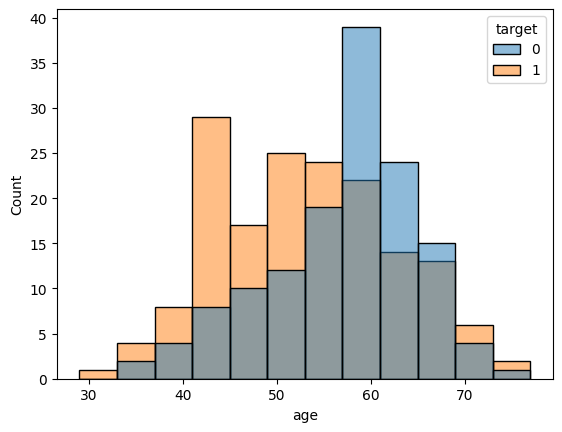

In [10]:
# check which age group has more cancer
sns.histplot(x="age",data=df,hue="target")

([<matplotlib.patches.Wedge at 0x79cfd5ccdd90>,
 [Text(-0.5986246866466376, 0.9228480289501707, '1'),
  Text(0.5986247673245755, -0.9228479766167329, '0')],
 [Text(-0.3265225563527114, 0.5033716521546385, '68.3%'),
  Text(0.3265226003588593, -0.503371623609127, '31.7%')])

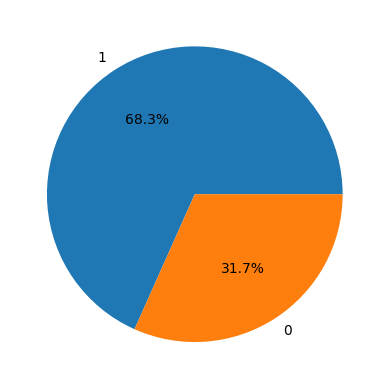

In [11]:
# drawing piechart to check whether which gender has more cancer using groupby
df.groupby("sex")["target"].value_counts()
plt.pie(df['sex'].value_counts(), labels=df['sex'].value_counts().index, autopct='%1.1f%%')

In [12]:
#Divide data into input and output
X = df.drop("target",axis=1)
y = df["target"]

In [13]:
#Split data for training and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [14]:
#Training the model
model = LogisticRegression()
model.fit(Xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [15]:
# Performing predictions
ypred = model.predict(Xtest)
ypred

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1])

In [16]:
# Confusion Matrix
confusion_matrix(ytest,ypred)

array([[32,  9],
       [ 8, 42]])

In [17]:
# Printing Classification Report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91



In [18]:
# Training and Testing Efficiency
print("Training Efficiency: ", model.score(Xtrain,ytrain))
print("Testing Efficiency: ", model.score(Xtest,ytest))

Training Efficiency:  0.8679245283018868
Testing Efficiency:  0.8131868131868132


In [19]:
# Testing model against new data --> for having heart attack
new_data = df.iloc[:1,:-1]
pred = model.predict(new_data)[0]
prob = model.predict_proba(new_data)
if pred ==1:
    print("Heart attack")
else:
    print("No heart Attack")

print("Probablitiy",prob)

Heart attack
Probablitiy [[0.12958216 0.87041784]]


In [20]:
# for having no heart attack
new_data = df.iloc[301:302,:-1]
pred = model.predict(new_data)[0]
prob = model.predict_proba(new_data)
if pred ==1:
    print("Heart attack")
else:
    print("No heart Attack")

print("Probablitiy",prob)

No heart Attack
Probablitiy [[0.97333353 0.02666647]]
